# Part 2 — Transformer scaling study (standard parameterization)**Course:** CS-GY 6923 · **Spec:** `optional-project-spring26.pdf` (Part 2, ~35%)Five decoder-only GPT sizes (Tiny→XL), AdamW, same token batch size, cosine LR + warmup,one epoch per size. LR sweep on Tiny only, then reuse that LR for all sizes.**Key insight:** Using a fixed Tiny-optimal LR on larger models will cause degradation —this is the **expected SP failure mode** that motivates Part 3 (µP).

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE = '/content/drive/MyDrive/svg_scaling_v2'
print("drive mounted")

Mounted at /content/drive
drive mounted


In [2]:
!pip install -q torch numpy matplotlib scipy tqdm seaborn

In [3]:
import json, math, time, random, gc, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.1 GB


In [4]:
# load metadata from Part 1
with open(f'{DRIVE}/data/meta.json') as f:
    meta = json.load(f)

VOCAB = meta['vocab_size']
PAD = meta['pad']
BOS = meta['bos']
EOS = meta['eos']
print(f"vocab={VOCAB}, pad={PAD}, bos={BOS}, eos={EOS}")

print("loading tokens...")
train_toks = np.load(f'{DRIVE}/data/train.npy', mmap_mode='r')
val_toks   = np.load(f'{DRIVE}/data/val.npy',   mmap_mode='r')
print(f"train: {len(train_toks):,} | val: {len(val_toks):,}")

vocab=4096, pad=0, bos=2, eos=3
loading tokens...
train: 112,654,174 | val: 1,139,210


## 2.1 Dataset and model

In [5]:
SEQ_LEN = 512
BATCH = 64  # 64 * 512 = 32768 tokens per batch

class TokenDataset(Dataset):
    def __init__(self, tokens, seq_len):
        self.seq_len = seq_len
        if isinstance(tokens, torch.Tensor):
            self._use_torch = True
            self._buf = tokens
            self._np = None
        else:
            self._use_torch = False
            self._buf = None
            self._np = np.asarray(tokens)
        ntok = len(tokens) if not self._use_torch else len(self._buf)
        self.n = (ntok - 1) // seq_len

    def __len__(self): return self.n

    def __getitem__(self, i):
        s = i * self.seq_len
        if self._use_torch:
            chunk = self._buf[s:s + self.seq_len + 1]
        else:
            chunk = torch.from_numpy(self._np[s:s + self.seq_len + 1].copy())
        return chunk[:-1].long(), chunk[1:].long()

train_ds = TokenDataset(train_toks, SEQ_LEN)
val_ds   = TokenDataset(val_toks, SEQ_LEN)
print(f"train batches: {len(train_ds)//BATCH} | val batches: {len(val_ds)//BATCH}")

train batches: 3437 | val batches: 34


In [6]:
HAS_FLASH = hasattr(F, 'scaled_dot_product_attention')
print(f"flash attention: {HAS_FLASH}")

class Attention(nn.Module):
    def __init__(self, d, n_heads, dropout=0.0, max_len=1024):
        super().__init__()
        assert d % n_heads == 0
        self.h = n_heads
        self.dh = d // n_heads
        self.qkv = nn.Linear(d, 3*d, bias=False)
        self.proj = nn.Linear(d, d, bias=False)
        self.drop = dropout
        self.out_drop = nn.Dropout(dropout)
        if not HAS_FLASH:
            self.register_buffer('mask', torch.tril(torch.ones(max_len, max_len)).view(1,1,max_len,max_len))

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.h, self.dh).transpose(1, 2)
        k = k.view(B, T, self.h, self.dh).transpose(1, 2)
        v = v.view(B, T, self.h, self.dh).transpose(1, 2)
        if HAS_FLASH:
            y = F.scaled_dot_product_attention(q, k, v, is_causal=True,
                    dropout_p=self.drop if self.training else 0.0)
        else:
            att = (q @ k.transpose(-2,-1)) / math.sqrt(self.dh)
            att = att.masked_fill(self.mask[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            y = att @ v
        y = y.transpose(1,2).contiguous().view(B, T, C)
        return self.out_drop(self.proj(y))


class Block(nn.Module):
    def __init__(self, d, n_heads, d_ff, dropout=0.0, max_len=1024):
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.attn = Attention(d, n_heads, dropout, max_len)
        self.ln2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(
            nn.Linear(d, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d), nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class GPT(nn.Module):
    def __init__(self, vocab, d, n_layers, n_heads, d_ff, max_len=512, dropout=0.0):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab, d)
        self.pos_emb = nn.Embedding(max_len, d)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(d, n_heads, d_ff, dropout, max_len) for _ in range(n_layers)])
        self.ln = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)
        self.head.weight = self.tok_emb.weight  # weight tying

        self.apply(self._init)
        for b in self.blocks:
            nn.init.normal_(b.attn.proj.weight, std=0.02/math.sqrt(2*n_layers))
            nn.init.normal_(b.ff[-2].weight, std=0.02/math.sqrt(2*n_layers))

    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.drop(self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device)))
        for b in self.blocks: x = b(x)
        logits = self.head(self.ln(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=PAD)
        return logits, loss

    def n_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


CONFIGS = {
    'Tiny':   dict(d=128,  n_layers=4,  n_heads=4,  d_ff=512),
    'Small':  dict(d=192,  n_layers=6,  n_heads=6,  d_ff=768),
    'Medium': dict(d=384,  n_layers=6,  n_heads=6,  d_ff=1536),
    'Large':  dict(d=512,  n_layers=10, n_heads=8,  d_ff=2048),
    'XL':     dict(d=768,  n_layers=12, n_heads=12, d_ff=3072),
}

print(f"{'name':<8} {'params':>12}")
for name, cfg in CONFIGS.items():
    m = GPT(VOCAB, **cfg, max_len=SEQ_LEN)
    print(f"{name:<8} {m.n_params():>12,}")
    del m
gc.collect()

flash attention: True
name           params
Tiny        1,381,120
Small       3,549,696
Medium     12,407,808
Large      33,863,680
XL         88,558,080


30

## 2.2 Training loop

In [7]:
def cosine_lr(step, warmup, total, lr_max, lr_min=None):
    if lr_min is None:
        lr_min = lr_max * 0.1
    if step < warmup:
        return lr_max * (step + 1) / warmup
    if step >= total:
        return lr_min
    t = (step - warmup) / (total - warmup)
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * t))


@torch.no_grad()
def eval_loss(model, ds, n_batches=100):
    model.eval()
    loader = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=0)
    losses = []
    for i, (x, y) in enumerate(loader):
        if i >= n_batches: break
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', dtype=torch.bfloat16, enabled=torch.cuda.is_available()):
            _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return float(np.mean(losses))


def train(model, train_ds, val_ds, lr, epochs=1, tag="model"):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.1)
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())
    train_workers = 2 if torch.cuda.is_available() else 0
    loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                        num_workers=train_workers, pin_memory=torch.cuda.is_available(),
                        drop_last=True, persistent_workers=(train_workers > 0))

    total = len(loader) * epochs
    warmup = min(total // 10, 300)

    history = {'train': [], 'val': [], 'val_steps': [], 'steps': []}
    step = 0
    t0 = time.time()
    running = 0.0
    n_running = 0
    diverged = False

    print(f"  {tag}: {model.n_params():,} params | lr={lr:.1e} | {total} steps")
    model.train()

    for _ in range(epochs):
        for x, y in loader:
            cur_lr = cosine_lr(step, warmup, total, lr)
            for g in opt.param_groups: g['lr'] = cur_lr

            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', dtype=torch.bfloat16, enabled=torch.cuda.is_available()):
                _, loss = model(x, y)

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            opt.zero_grad(set_to_none=True)

            step += 1
            running += loss.item()
            n_running += 1

            if loss.item() > 20 or math.isnan(loss.item()):
                print(f"  diverged at step {step}!")
                diverged = True
                break

            if step % 200 == 0 and n_running > 0:
                history['train'].append(running / n_running)
                history['steps'].append(step)
                running = 0.0
                n_running = 0

            if step % 500 == 0:
                vl = eval_loss(model, val_ds)
                history['val'].append(vl)
                history['val_steps'].append(step)
                tl = history['train'][-1] if history['train'] else 0
                print(f"    step {step}/{total} | train={tl:.4f} val={vl:.4f} | {time.time()-t0:.0f}s")
                model.train()

        if diverged: break

    final_val = eval_loss(model, val_ds) if not diverged else float('inf')
    elapsed = time.time() - t0
    gpu_gb = torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else 0

    print(f"  done: val={final_val:.4f} | {elapsed:.0f}s | {gpu_gb:.1f}GB GPU")

    return {
        'val': final_val, 'history': history, 'time': elapsed,
        'gpu_gb': gpu_gb,
        'tps': (step * BATCH * SEQ_LEN) / max(elapsed, 1e-9),
        'n_params': model.n_params(), 'diverged': diverged,
    }

## 2.3 LR sweep on Tiny

=== LR sweep on Tiny ===

  tiny_lr3e-04: 1,381,120 params | lr=3.0e-04 | 3437 steps
    step 500/3437 | train=2.1298 val=1.4893 | 14s
    step 1000/3437 | train=1.1833 val=1.1516 | 21s
    step 1500/3437 | train=1.0514 val=1.0151 | 29s
    step 2000/3437 | train=0.9718 val=0.9643 | 36s
    step 2500/3437 | train=0.9514 val=0.9375 | 44s
    step 3000/3437 | train=0.9332 val=0.9221 | 51s
  done: val=0.9141 | 57s | 2.3GB GPU
  tiny_lr6e-04: 1,381,120 params | lr=6.0e-04 | 3437 steps
    step 500/3437 | train=1.6216 val=1.2653 | 7s
    step 1000/3437 | train=1.0337 val=1.0054 | 15s
    step 1500/3437 | train=0.9524 val=0.9242 | 22s
    step 2000/3437 | train=0.8611 val=0.8468 | 29s
    step 2500/3437 | train=0.8221 val=0.8044 | 37s
    step 3000/3437 | train=0.7921 val=0.7816 | 44s
  done: val=0.7717 | 51s | 2.3GB GPU
  tiny_lr1e-03: 1,381,120 params | lr=1.0e-03 | 3437 steps
    step 500/3437 | train=1.4548 val=1.1696 | 8s
    step 1000/3437 | train=0.9878 val=0.9637 | 15s
    step 1500/

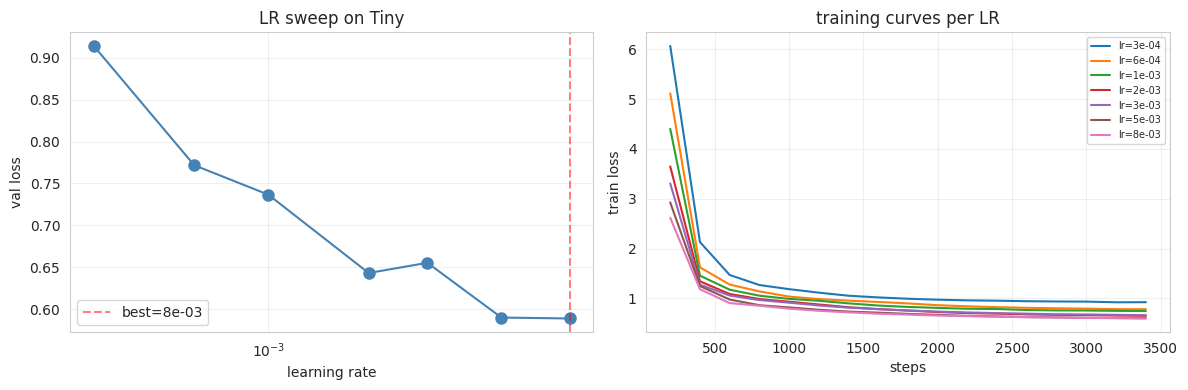

In [8]:
lr_candidates = [3e-4, 6e-4, 1e-3, 2e-3, 3e-3, 5e-3, 8e-3]
sweep_results = []

print("=== LR sweep on Tiny ===\n")
for lr in lr_candidates:
    torch.cuda.reset_peak_memory_stats()
    m = GPT(VOCAB, **CONFIGS['Tiny'], max_len=SEQ_LEN)
    r = train(m, train_ds, val_ds, lr=lr, tag=f"tiny_lr{lr:.0e}")
    sweep_results.append({'lr': lr, 'val': r['val'], 'hist': r['history']})
    del m
    torch.cuda.empty_cache()
    gc.collect()

best = min(sweep_results, key=lambda x: x['val'])
BEST_LR = best['lr']
print(f"\nbest LR: {BEST_LR:.1e} (val={best['val']:.4f})")

TINY_PARAMS = GPT(VOCAB, **CONFIGS['Tiny'], max_len=SEQ_LEN).n_params()

with open(f'{DRIVE}/results/lr_sweep.json', 'w') as f:
    json.dump({
        'results': [{'lr': r['lr'], 'val': r['val']} for r in sweep_results],
        'best_lr': BEST_LR,
        'tiny_params': TINY_PARAMS,
    }, f, indent=2)

# plot LR sweep
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
lrs = [r['lr'] for r in sweep_results]
vals = [r['val'] for r in sweep_results]
ax1.semilogx(lrs, vals, 'o-', color='steelblue', ms=8)
ax1.axvline(BEST_LR, color='red', ls='--', alpha=0.5, label=f'best={BEST_LR:.0e}')
ax1.set_xlabel('learning rate')
ax1.set_ylabel('val loss')
ax1.set_title('LR sweep on Tiny')
ax1.legend()
ax1.grid(True, alpha=0.3)

for r in sweep_results:
    h = r['hist']
    if h['train']:
        ax2.plot(h['steps'], h['train'], label=f"lr={r['lr']:.0e}")
ax2.set_xlabel('steps')
ax2.set_ylabel('train loss')
ax2.set_title('training curves per LR')
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE}/plots/lr_sweep.png', dpi=150)
plt.show()

## 2.4 Train all 5 model sizes**Run A — Fixed LR (per spec):** Same LR for every size. This will show degradation atLarge/XL — that's the expected SP behavior and motivates Part 3.**Run B — Scaled LR:** Use sqrt-scaling `lr(N) = lr_tiny * sqrt(N_tiny/N)` as thestandard SP heuristic. This gives the proper SP scaling curve for power-law fitting.

In [9]:
sp_results = {}

# ──── Run A: Fixed LR (per spec) ────
print(f"=== Run A: fixed LR={BEST_LR:.2e} (tuned on Tiny) ===\n")
for name, cfg in CONFIGS.items():
    torch.cuda.reset_peak_memory_stats()
    m = GPT(VOCAB, **cfg, max_len=SEQ_LEN)
    r = train(m, train_ds, val_ds, lr=BEST_LR, tag=f"SP_fixed_{name}")

    sp_results[name] = {
        'val_fixed_lr': r['val'],
        'n_params': r['n_params'],
        'history_fixed': r['history'],
        'time': r['time'],
        'gpu_gb': r['gpu_gb'],
        'tps': r['tps'],
        'diverged_fixed': r['diverged'],
        'fixed_lr': BEST_LR,
    }

    # save checkpoint
    torch.save(m.state_dict(), f'{DRIVE}/checkpoints/sp_fixed_{name}.pt')
    del m
    torch.cuda.empty_cache()
    gc.collect()

print("\n=== Fixed LR results ===")
print(f"{'model':<8} {'params':>12} {'lr':>10} {'val':>9} {'note'}")
print("-" * 55)
for name in CONFIGS:
    r = sp_results[name]
    note = "DIVERGED" if r['diverged_fixed'] else ""
    print(f"{name:<8} {r['n_params']:>12,} {r['fixed_lr']:>10.2e} {r['val_fixed_lr']:>9.4f}  {note}")

=== Run A: fixed LR=8.00e-03 (tuned on Tiny) ===

  SP_fixed_Tiny: 1,381,120 params | lr=8.0e-03 | 3437 steps
    step 500/3437 | train=1.1896 val=0.8992 | 7s
    step 1000/3437 | train=0.7821 val=0.7493 | 15s
    step 1500/3437 | train=0.7114 val=0.6809 | 22s
    step 2000/3437 | train=0.6541 val=0.6429 | 30s
    step 2500/3437 | train=0.6322 val=0.6170 | 37s
    step 3000/3437 | train=0.6059 val=0.5975 | 45s
  done: val=0.5898 | 51s | 2.3GB GPU
  SP_fixed_Small: 3,549,696 params | lr=8.0e-03 | 3437 steps
    step 500/3437 | train=1.0561 val=0.8661 | 11s
    step 1000/3437 | train=0.7575 val=0.7256 | 22s
    step 1500/3437 | train=0.6794 val=0.6463 | 33s
    step 2000/3437 | train=0.6124 val=0.6001 | 44s
    step 2500/3437 | train=0.5883 val=0.5694 | 55s
    step 3000/3437 | train=0.5588 val=0.5488 | 67s
  done: val=0.5398 | 76s | 3.1GB GPU
  SP_fixed_Medium: 12,407,808 params | lr=8.0e-03 | 3437 steps
    step 500/3437 | train=0.9706 val=0.8736 | 17s
    step 1000/3437 | train=0.8194

In [10]:
# ──── Run B: Scaled LR ────
print(f"\n=== Run B: sqrt-scaled LR from Tiny ===\n")
for name, cfg in CONFIGS.items():
    torch.cuda.reset_peak_memory_stats()
    m = GPT(VOCAB, **cfg, max_len=SEQ_LEN)
    n_params = m.n_params()
    scaled_lr = BEST_LR * math.sqrt(TINY_PARAMS / n_params)

    r = train(m, train_ds, val_ds, lr=scaled_lr, tag=f"SP_scaled_{name}")

    sp_results[name]['val'] = r['val']
    sp_results[name]['history'] = r['history']
    sp_results[name]['scaled_lr'] = scaled_lr
    sp_results[name]['diverged'] = r['diverged']

    torch.save(m.state_dict(), f'{DRIVE}/checkpoints/sp_{name}.pt')
    del m
    torch.cuda.empty_cache()
    gc.collect()

print("\n=== Scaled LR results ===")
print(f"{'model':<8} {'params':>12} {'scaled_lr':>10} {'val':>9}")
print("-" * 50)
for name in CONFIGS:
    r = sp_results[name]
    print(f"{name:<8} {r['n_params']:>12,} {r['scaled_lr']:>10.2e} {r['val']:>9.4f}")

vals = [sp_results[n]['val'] for n in CONFIGS]
print(f"\nmonotonically decreasing: {all(a >= b for a, b in zip(vals, vals[1:]))}")

# save all results
with open(f'{DRIVE}/results/sp_results.json', 'w') as f:
    # strip non-serializable history for JSON
    save_dict = {}
    for name, r in sp_results.items():
        save_dict[name] = {k: v for k, v in r.items() if k not in ('history_fixed',)}
    json.dump(save_dict, f, indent=2, default=str)


=== Run B: sqrt-scaled LR from Tiny ===

  SP_scaled_Tiny: 1,381,120 params | lr=8.0e-03 | 3437 steps
    step 500/3437 | train=1.2140 val=0.8953 | 8s
    step 1000/3437 | train=0.7841 val=0.7512 | 15s
    step 1500/3437 | train=0.6978 val=0.6709 | 23s
    step 2000/3437 | train=0.6467 val=0.6351 | 30s
    step 2500/3437 | train=0.6248 val=0.6097 | 38s
    step 3000/3437 | train=0.6011 val=0.5903 | 45s
  done: val=0.5834 | 52s | 2.3GB GPU
  SP_scaled_Small: 3,549,696 params | lr=5.0e-03 | 3437 steps
    step 500/3437 | train=1.1052 val=0.8639 | 11s
    step 1000/3437 | train=0.7174 val=0.6791 | 22s
    step 1500/3437 | train=0.6414 val=0.6194 | 33s
    step 2000/3437 | train=0.5939 val=0.5854 | 44s
    step 2500/3437 | train=0.5732 val=0.5610 | 56s
    step 3000/3437 | train=0.5514 val=0.5431 | 67s
  done: val=0.5348 | 77s | 3.1GB GPU
  SP_scaled_Medium: 12,407,808 params | lr=2.7e-03 | 3437 steps
    step 500/3437 | train=0.9896 val=0.8421 | 17s
    step 1000/3437 | train=0.6926 val=

## 2.5 Scaling plot and power law fit

SP fit (scaled LR): L = 7190.9784 * N^(-0.8107) + 0.5061  R2=0.9559


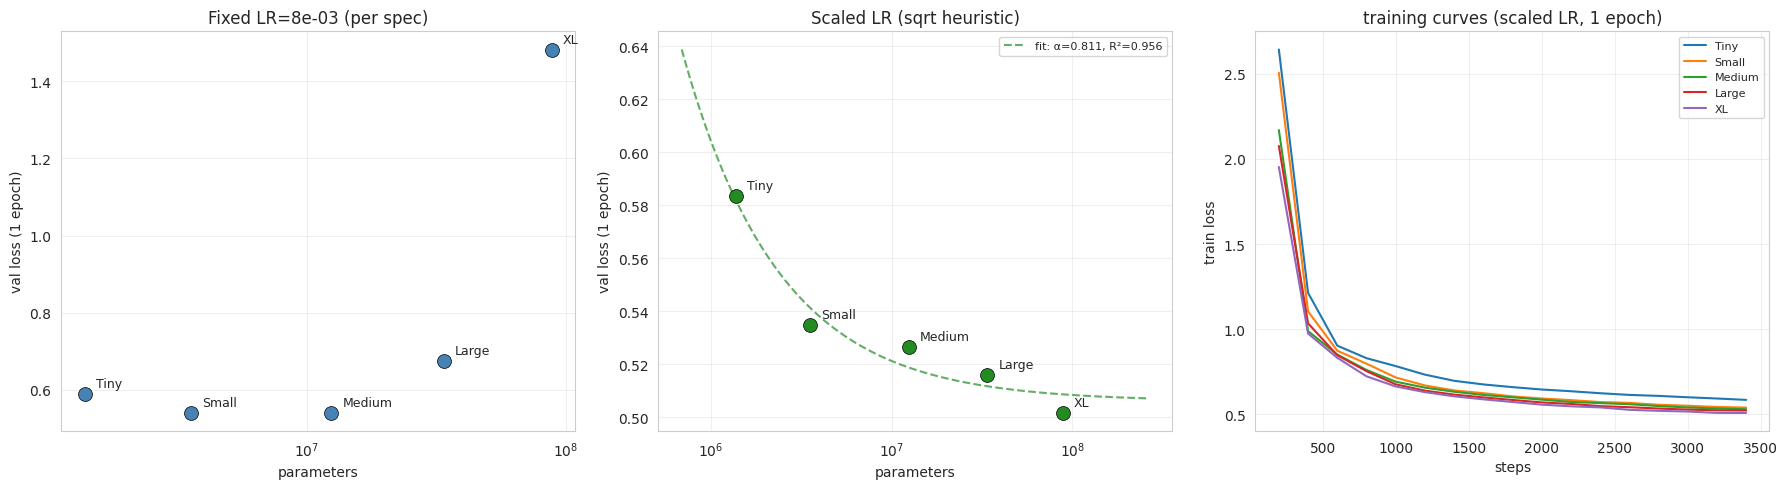

In [11]:
def power_law(N, a, alpha, c):
    return a * np.power(N, -alpha) + c

def fit_power_law(params, losses):
    params = np.asarray(params, dtype=float)
    losses = np.asarray(losses, dtype=float)
    try:
        popt, pcov = curve_fit(power_law, params, losses,
                               p0=[10.0, 0.1, min(losses) * 0.9],
                               bounds=([0, 0.001, 0], [1e6, 5.0, max(losses)]),
                               maxfev=10000)
        return popt
    except Exception as e:
        print(f"  curve_fit failed: {e}, trying grid search")
        # fallback grid search
        x = np.log(np.maximum(params, 1.0))
        c_max = float(np.min(losses) - 1e-4)
        if c_max <= 1e-6: return None
        c_grid = np.linspace(max(0, c_max - 2), c_max, 600)
        best, best_res = None, float('inf')
        for c in c_grid:
            rem = losses - c
            if np.any(rem <= 1e-8): continue
            y = np.log(rem)
            A = np.vstack([x, np.ones_like(x)]).T
            try:
                sol, res_arr, _, _ = np.linalg.lstsq(A, y, rcond=None)
                alpha_c = float(np.clip(-sol[0], 1e-4, 2.5))
                a_c = float(np.exp(sol[1]))
                pred = power_law(params, a_c, alpha_c, float(c))
                res = float(np.sum((losses - pred) ** 2))
                if np.isfinite(res) and res < best_res:
                    best_res = res
                    best = np.array([a_c, alpha_c, float(c)])
            except: pass
        return best

def r_squared(params, losses, popt):
    pred = power_law(params, *popt)
    ss_res = np.sum((losses - pred) ** 2)
    ss_tot = np.sum((losses - np.mean(losses)) ** 2)
    return 1.0 - ss_res / max(ss_tot, 1e-12)


ORDER = list(CONFIGS.keys())
# Use scaled-LR results for the canonical SP scaling curve
p_all = np.array([sp_results[n]['n_params'] for n in ORDER])
L_all = np.array([sp_results[n]['val'] for n in ORDER])
L_fixed = np.array([sp_results[n]['val_fixed_lr'] for n in ORDER])

popt = fit_power_law(p_all, L_all)
r2 = r_squared(p_all, L_all, popt) if popt is not None else None

if popt is not None:
    a, alpha, c = popt
    print(f"SP fit (scaled LR): L = {a:.4f} * N^(-{alpha:.4f}) + {c:.4f}  R2={r2:.4f}")
    with open(f'{DRIVE}/results/sp_fit.json', 'w') as f:
        json.dump({
            'a': float(a), 'alpha': float(alpha), 'c': float(c),
            'r2': float(r2), 'fit_label': 'SP scaled-LR (all 5)',
            'excluded_xl': False, 'variant': 'scaled_lr',
        }, f, indent=2)
else:
    print("WARNING: power law fit failed!")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

xf = np.logspace(np.log10(p_all.min() * 0.5), np.log10(p_all.max() * 3), 200)

# Panel 1: Fixed LR (showing degradation)
ax = axes[0]
ax.scatter(p_all, L_fixed, s=100, c='steelblue', zorder=5, edgecolors='k', lw=0.5)
for name, p, l in zip(ORDER, p_all, L_fixed):
    ax.annotate(name, (p, l), textcoords='offset points', xytext=(8, 5), fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('parameters')
ax.set_ylabel('val loss (1 epoch)')
ax.set_title(f'Fixed LR={BEST_LR:.0e} (per spec)')
ax.grid(True, alpha=0.3)

# Panel 2: Scaled LR (proper scaling curve)
ax = axes[1]
ax.scatter(p_all, L_all, s=100, c='forestgreen', zorder=5, edgecolors='k', lw=0.5)
if popt is not None:
    ax.plot(xf, power_law(xf, *popt), '--', color='forestgreen', alpha=0.7,
            label=f'fit: α={popt[1]:.3f}, R²={r2:.3f}')
for name, p, l in zip(ORDER, p_all, L_all):
    ax.annotate(name, (p, l), textcoords='offset points', xytext=(8, 5), fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('parameters')
ax.set_ylabel('val loss (1 epoch)')
ax.set_title('Scaled LR (sqrt heuristic)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: Training curves
ax = axes[2]
for name, r in sp_results.items():
    h = r['history']
    if h['train']:
        ax.plot(h['steps'], h['train'], label=name)
ax.set_xlabel('steps')
ax.set_ylabel('train loss')
ax.set_title('training curves (scaled LR, 1 epoch)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE}/plots/scaling_sp.png', dpi=150)
plt.show()

## Done with Part 2Saved:- `results/lr_sweep.json`, `sp_results.json`, `sp_fit.json`- `checkpoints/sp_*.pt`- `plots/lr_sweep.png`, `plots/scaling_sp.png`